# Assignment 4 — Pet Emotion Recognition with Inception V3

**Dataset:** 1 000 face images across 4 emotion classes → `Angry | happy | Other | Sad`  
**Part 1:** Inception V3 implemented **from scratch** using PyTorch  
**Part 2:** Same network loaded with **ImageNet pre-trained weights** (transfer learning)

## 1 — Imports & Configuration

In [3]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models

from tqdm.auto import tqdm          # per-batch progress bars

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
)

# ── Global hyperparameters ─────────────────────────────────────────────────────
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR    = "/content/drive/MyDrive/Colab Notebooks/Dataset"
NUM_CLASSES = 4
IMG_SIZE    = 299      # Inception V3 standard input
BATCH_SIZE  = 32
EPOCHS      = 30
LR_SCRATCH  = 1e-3    # higher LR for random init
LR_TL       = 1e-4    # lower LR for fine-tuning (avoids destroying pretrained weights)
SEED        = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU    : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Classes  : {NUM_CLASSES}  |  Epochs: {EPOCHS}  |  Batch: {BATCH_SIZE}")

from google.colab import drive
drive.mount('/content/drive')

PyTorch  : 2.10.0+cu128
Device   : cuda
  GPU    : Tesla T4
  VRAM   : 15.6 GB
Classes  : 4  |  Epochs: 30  |  Batch: 32
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2 — Inception V3 Architecture (from scratch)

The Inception V3 paper (Szegedy et al., 2016) introduced several key ideas over the original Inception (GoogLeNet):

1. **Factorised convolutions** — replace large `n×n` kernels with cheaper `1×n` + `n×1` sequences  
2. **Grid size reduction** — dedicated blocks that simultaneously decrease spatial size and increase depth without an information bottleneck  
3. **Expanded filter banks** at the deepest layers (8×8 feature maps)  
4. **Auxiliary classifier** — a side branch attached partway through the network that provides an extra gradient signal during training (weighted at 0.4)

### Building blocks (bottom-up)

```
BasicConv2d        →  Conv2d (no bias) → BatchNorm → ReLU
InceptionA        →  35×35 maps, 4 branches, 256–288 ch
InceptionB        →  35→17 grid reduction
InceptionC        →  17×17 maps, factorised 1×7 / 7×1 convolutions, 768 ch
InceptionD        →  17→8  grid reduction
InceptionE        →  8×8  maps, expanded parallel branches, 2048 ch
InceptionAux      →  auxiliary classifier head (attached to Mixed_6e output)
InceptionV3Scratch→  full assembled network
```

### Data flow & spatial dimensions
```
Input       (B, 3, 299, 299)
Stem        → (B, 192, 35, 35)
Mixed_5b/c/d (InceptionA ×3)  → (B, 288, 35, 35)
Mixed_6a    (InceptionB)       → (B, 768, 17, 17)
Mixed_6b-6e (InceptionC ×4)   → (B, 768, 17, 17)
  └─ AuxLogits branch here
Mixed_7a    (InceptionD)       → (B,1280,  8,  8)
Mixed_7b/7c (InceptionE ×2)   → (B,2048,  8,  8)
AdaptiveAvgPool + Dropout + FC → (B, num_classes)
```

### 2.1 — `BasicConv2d`: the shared primitive

Every convolution in Inception V3 follows the same pattern:  
`Conv2d (no bias)` → `BatchNorm2d` → `ReLU`  

The bias is *omitted* because BatchNorm already has a learnable shift (`β`) that plays the same role — adding a separate bias would be redundant and waste parameters.

In [4]:
class BasicConv2d(nn.Module):
    """
    The atomic building block used everywhere in Inception V3.
    Conv2d (no bias)  →  BatchNorm2d  →  ReLU
    """
    def __init__(self, in_ch: int, out_ch: int, **kwargs):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, bias=False, **kwargs)
        self.bn   = nn.BatchNorm2d(out_ch, eps=0.001)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.relu(self.bn(self.conv(x)))

### 2.2 — `InceptionA`: 4-branch module (35×35 feature maps)

The original Inception module runs **4 parallel paths** and concatenates their outputs along the channel dimension. This lets the network simultaneously look at the input with different receptive field sizes:

| Branch | Operation | Output ch |
|--------|-----------|-----------|
| b1 | 1×1 conv | 64 |
| b2 | 1×1 → 5×5 conv | 64 |
| b3 | 1×1 → 3×3 → 3×3 conv | 96 |
| b4 | AvgPool → 1×1 conv | `pool_features` |

Using a 5×5 directly is expensive; using two consecutive 3×3 convolutions gives the same receptive field with fewer parameters — but InceptionA keeps a genuine 5×5 here (it's only one layer deep, so it's acceptable at this early stage).

In [5]:
class InceptionA(nn.Module):
    """
    4-branch Inception module operating on 35×35 feature maps.
    Channels per run: 192→256 (pool=32), 256→288 (pool=64), 288→288 (pool=64).
    """
    def __init__(self, in_ch: int, pool_features: int):
        super().__init__()
        # Branch 1: direct 1×1
        self.b1 = BasicConv2d(in_ch, 64, kernel_size=1)

        # Branch 2: 1×1 bottleneck → 5×5
        self.b2 = nn.Sequential(
            BasicConv2d(in_ch, 48, kernel_size=1),
            BasicConv2d(48,    64, kernel_size=5, padding=2),
        )

        # Branch 3: 1×1 → 3×3 → 3×3  (same receptive field as 7×7, cheaper)
        self.b3 = nn.Sequential(
            BasicConv2d(in_ch, 64, kernel_size=1),
            BasicConv2d(64,    96, kernel_size=3, padding=1),
            BasicConv2d(96,    96, kernel_size=3, padding=1),
        )

        # Branch 4: average pool → 1×1 (aggregates spatial context)
        self.b4 = nn.Sequential(
            nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
            BasicConv2d(in_ch, pool_features, kernel_size=1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Concatenate all branches along the channel axis
        return torch.cat([self.b1(x), self.b2(x), self.b3(x), self.b4(x)], dim=1)

### 2.3 — `InceptionB`: Grid Reduction (35→17)

Instead of a naive max-pool (which wastes learned representations) or a strided conv (which can create a representational bottleneck), Inception V3 uses a **parallel stride-2 reduction**:

- Branch 1: plain 3×3 stride-2 → 384 ch  
- Branch 2: 1×1 → 3×3 → 3×3 stride-2 → 96 ch  
- Branch 3: MaxPool stride-2 → passes `in_ch` channels through unchanged  

Total output: `384 + 96 + in_ch` at spatial size 17×17.

In [6]:
class InceptionB(nn.Module):
    """
    Grid reduction: 35×35 → 17×17.
    3 parallel branches all using stride 2 to halve spatial size.
    Output channels: 384 + 96 + in_ch
    """
    def __init__(self, in_ch: int):
        super().__init__()
        # Branch 1: single strided conv
        self.b1 = BasicConv2d(in_ch, 384, kernel_size=3, stride=2)

        # Branch 2: deep path before striding
        self.b2 = nn.Sequential(
            BasicConv2d(in_ch, 64, kernel_size=1),
            BasicConv2d(64,    96, kernel_size=3, padding=1),
            BasicConv2d(96,    96, kernel_size=3, stride=2),
        )

        # Branch 3: max-pool (no learnable params, preserves info cheaply)
        self.b3 = nn.MaxPool2d(kernel_size=3, stride=2)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.cat([self.b1(x), self.b2(x), self.b3(x)], dim=1)

### 2.4 — `InceptionC`: Factorised convolutions (17×17, 768 ch)

The key optimisation in Inception V3: an `n×n` convolution is split into two cheaper **asymmetric** convolutions `1×n` followed by `n×1`. For `n=7`:
- A single `7×7` on 192 channels → `192 × 7 × 7 = 9408` multiply-adds per output pixel  
- Two factorised convs `1×7` + `7×1` on 192 ch → `2 × 192 × 1 × 7 = 2688` — that's ~**3.5× cheaper**!

All 4 branches produce 192 channels → total output: **768 channels**.  
Used 4 consecutive times (Mixed_6b → Mixed_6e) with `channels_7x7` growing from 128 → 160 → 160 → 192.

In [7]:
class InceptionC(nn.Module):
    """
    17×17 module with factorised 1×7 / 7×1 convolutions.
    Each of the 4 branches outputs 192 channels → total 768 ch.
    """
    def __init__(self, in_ch: int, channels_7x7: int):
        super().__init__()
        c = channels_7x7   # intermediate width, grows 128→160→160→192

        # Branch 1: plain 1×1
        self.b1 = BasicConv2d(in_ch, 192, kernel_size=1)

        # Branch 2: 1×1 → 1×7 → 7×1  (single factorised path)
        self.b2 = nn.Sequential(
            BasicConv2d(in_ch, c,   kernel_size=1),
            BasicConv2d(c,     c,   kernel_size=(1, 7), padding=(0, 3)),
            BasicConv2d(c,     192, kernel_size=(7, 1), padding=(3, 0)),
        )

        # Branch 3: 1×1 → 7×1 → 1×7 → 7×1 → 1×7  (double factorised path, wider RF)
        self.b3 = nn.Sequential(
            BasicConv2d(in_ch, c,   kernel_size=1),
            BasicConv2d(c,     c,   kernel_size=(7, 1), padding=(3, 0)),
            BasicConv2d(c,     c,   kernel_size=(1, 7), padding=(0, 3)),
            BasicConv2d(c,     c,   kernel_size=(7, 1), padding=(3, 0)),
            BasicConv2d(c,     192, kernel_size=(1, 7), padding=(0, 3)),
        )

        # Branch 4: AvgPool → 1×1
        self.b4 = nn.Sequential(
            nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
            BasicConv2d(in_ch, 192, kernel_size=1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.cat([self.b1(x), self.b2(x), self.b3(x), self.b4(x)], dim=1)


class InceptionD(nn.Module):
    """
    Grid reduction: 17×17 → 8×8.
    Mirrors InceptionB but with factorised paths.
    Output channels: 320 + 192 + in_ch
    """
    def __init__(self, in_ch: int):
        super().__init__()
        self.b1 = nn.Sequential(
            BasicConv2d(in_ch, 192, kernel_size=1),
            BasicConv2d(192,   320, kernel_size=3, stride=2),
        )
        self.b2 = nn.Sequential(
            BasicConv2d(in_ch, 192, kernel_size=1),
            BasicConv2d(192,   192, kernel_size=(1, 7), padding=(0, 3)),
            BasicConv2d(192,   192, kernel_size=(7, 1), padding=(3, 0)),
            BasicConv2d(192,   192, kernel_size=3, stride=2),
        )
        self.b3 = nn.MaxPool2d(kernel_size=3, stride=2)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.cat([self.b1(x), self.b2(x), self.b3(x)], dim=1)

### 2.5 — `InceptionE`: Expanded filter banks (8×8, 2048 ch)

At the deepest stage (8×8 maps) saving computation matters less — there are very few spatial positions. Instead, the network **expands** the number of parallel feature detectors:

- Each of branches 2 and 3 further splits into **two** parallel asymmetric convolutions (`1×3` and `3×1`) whose outputs are concatenated. This produces very wide, fine-grained representations.
- Output: `320 + 384 + 384 + 384 + 384 + 192 = 2048` channels

### 2.6 — Auxiliary Classifier (`InceptionAux`)

Attached to the output of `Mixed_6e` (17×17, 768 ch). During **training** it contributes a regularising gradient signal weighted at **0.4** of the main loss. During inference it is disabled.

Architecture: `AvgPool(5, s=3)` → `1×1 conv, 128 ch` → `5×5 conv, 768 ch` → `Linear`

In [8]:
class InceptionE(nn.Module):
    """
    8×8 module with parallel 1×3 / 3×1 split inside each deep branch.
    Output: 320 + 768 + 768 + 192 = 2048 channels.
    """
    def __init__(self, in_ch: int):
        super().__init__()
        # Branch 1: 1×1
        self.b1 = BasicConv2d(in_ch, 320, kernel_size=1)

        # Branch 2: 1×1 reshape, then split into 1×3 and 3×1
        self.b2_reduce = BasicConv2d(in_ch, 384, kernel_size=1)
        self.b2a = BasicConv2d(384, 384, kernel_size=(1, 3), padding=(0, 1))
        self.b2b = BasicConv2d(384, 384, kernel_size=(3, 1), padding=(1, 0))

        # Branch 3: 1×1 → 3×3 → split into 1×3 and 3×1
        self.b3_reduce = BasicConv2d(in_ch, 448, kernel_size=1)
        self.b3_mid    = BasicConv2d(448,   384, kernel_size=3, padding=1)
        self.b3a = BasicConv2d(384, 384, kernel_size=(1, 3), padding=(0, 1))
        self.b3b = BasicConv2d(384, 384, kernel_size=(3, 1), padding=(1, 0))

        # Branch 4: AvgPool → 1×1
        self.b4 = nn.Sequential(
            nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
            BasicConv2d(in_ch, 192, kernel_size=1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b1  = self.b1(x)

        b2r = self.b2_reduce(x)
        b2  = torch.cat([self.b2a(b2r), self.b2b(b2r)], dim=1)   # 768 ch

        b3r = self.b3_reduce(x)
        b3m = self.b3_mid(b3r)
        b3  = torch.cat([self.b3a(b3m), self.b3b(b3m)], dim=1)   # 768 ch

        b4  = self.b4(x)

        return torch.cat([b1, b2, b3, b4], dim=1)                 # 2048 ch


class InceptionAux(nn.Module):
    """
    Auxiliary classifier branch, attached after Mixed_6e.
    Active only during training; provides additional gradient flow
    to earlier layers weighted at 0.4 of the main loss.
    """
    def __init__(self, in_ch: int, num_classes: int):
        super().__init__()
        self.pool  = nn.AvgPool2d(5, stride=3)              # 17×17 → 5×5
        self.conv0 = BasicConv2d(in_ch, 128, kernel_size=1)
        self.conv1 = BasicConv2d(128,   768, kernel_size=5) # 5×5 → 1×1
        self.fc    = nn.Linear(768, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool(x)
        x = self.conv0(x)
        x = self.conv1(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

### 2.7 — `InceptionV3Scratch`: the complete assembled network

This class wires all the blocks together in the canonical order and adds:
- **Kaiming-normal** weight init for Conv2d (suitable for ReLU activations)
- **Ones/Zeros** init for BatchNorm γ/β (standard)
- **Truncated-normal** init for Linear layers (prevents logit explosion at start)
- `AdaptiveAvgPool2d((1, 1))` → removes the fixed 8×8 spatial dependency, making the head resolution-agnostic

In [9]:
class InceptionV3Scratch(nn.Module):
    """
    Full Inception V3 built from scratch.
    Input  : (B, 3, 299, 299)
    Output : (logits, aux_logits)  — aux_logits is None at eval time
    """
    def __init__(self, num_classes: int = 4, aux_logits: bool = True,
                 dropout: float = 0.5):
        super().__init__()
        self.aux_logits = aux_logits

        # ── Stem (entry flow) ──────────────────────────────────────────────┐
        # Spatial: 299→149→147→147→73→73→71→35                              │
        self.Conv2d_1a = BasicConv2d(3,   32,  kernel_size=3, stride=2)  # s=2 │
        self.Conv2d_2a = BasicConv2d(32,  32,  kernel_size=3)             #     │
        self.Conv2d_2b = BasicConv2d(32,  64,  kernel_size=3, padding=1)  #     │
        self.maxpool1  = nn.MaxPool2d(3, stride=2)                        # s=2 │
        self.Conv2d_3b = BasicConv2d(64,  80,  kernel_size=1)             #     │
        self.Conv2d_4a = BasicConv2d(80,  192, kernel_size=3)             #     │
        self.maxpool2  = nn.MaxPool2d(3, stride=2)                        # s=2 ┘

        # ── 3 × Inception-A (35×35) ───────────────────────────────────────
        self.Mixed_5b = InceptionA(192, pool_features=32)  # out = 256
        self.Mixed_5c = InceptionA(256, pool_features=64)  # out = 288
        self.Mixed_5d = InceptionA(288, pool_features=64)  # out = 288

        # ── Grid reduction: 35→17 ─────────────────────────────────────────
        self.Mixed_6a = InceptionB(288)   # out = 768

        # ── 4 × Inception-C (17×17) ───────────────────────────────────────
        self.Mixed_6b = InceptionC(768, channels_7x7=128)
        self.Mixed_6c = InceptionC(768, channels_7x7=160)
        self.Mixed_6d = InceptionC(768, channels_7x7=160)
        self.Mixed_6e = InceptionC(768, channels_7x7=192)

        # ── Auxiliary branch hooks from Mixed_6e output ────────────────────
        if aux_logits:
            self.AuxLogits = InceptionAux(768, num_classes)

        # ── Grid reduction: 17→8 ──────────────────────────────────────────
        self.Mixed_7a = InceptionD(768)   # out = 1280

        # ── 2 × Inception-E (8×8) ─────────────────────────────────────────
        self.Mixed_7b = InceptionE(1280)  # out = 2048
        self.Mixed_7c = InceptionE(2048)  # out = 2048

        # ── Classification head ────────────────────────────────────────────
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=dropout)
        self.fc      = nn.Linear(2048, num_classes)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.01)
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor):
        x = self.Conv2d_1a(x)   # → (B, 32, 149, 149)
        x = self.Conv2d_2a(x)   # → (B, 32, 147, 147)
        x = self.Conv2d_2b(x)   # → (B, 64, 147, 147)
        x = self.maxpool1(x)    # → (B, 64,  73,  73)
        x = self.Conv2d_3b(x)   # → (B, 80,  73,  73)
        x = self.Conv2d_4a(x)   # → (B,192,  71,  71)
        x = self.maxpool2(x)    # → (B,192,  35,  35)

        x = self.Mixed_5b(x)   # → (B,256, 35, 35)
        x = self.Mixed_5c(x)   # → (B,288, 35, 35)
        x = self.Mixed_5d(x)   # → (B,288, 35, 35)

        x = self.Mixed_6a(x)   # → (B,768, 17, 17)

        x = self.Mixed_6b(x)   # → (B,768, 17, 17)
        x = self.Mixed_6c(x)
        x = self.Mixed_6d(x)
        x = self.Mixed_6e(x)

        # Auxiliary classifier fires during training only
        aux = self.AuxLogits(x) if (self.aux_logits and self.training) else None

        x = self.Mixed_7a(x)   # → (B,1280,  8,  8)
        x = self.Mixed_7b(x)   # → (B,2048,  8,  8)
        x = self.Mixed_7c(x)   # → (B,2048,  8,  8)

        x = self.avgpool(x)    # → (B,2048,  1,  1)
        x = self.dropout(x)
        x = x.view(x.size(0), -1)  # → (B,2048)
        x = self.fc(x)             # → (B, num_classes)

        return x, aux

## 3 — Data Loading & Augmentation

### Why augmentation?
With only 1000 training images split across 4 classes (250 per class), the model can easily overfit. Augmentation artificially multiplies the effective dataset size by showing the model the same images with random perturbations.

### Augmentation policy (training only)
| Transform | Purpose |
|-----------|---------|
| `Resize(320)` + `RandomCrop(299)` | Random positional jitter while keeping 299×299 input |
| `RandomHorizontalFlip` | Animal faces are mostly symmetric |
| `RandomVerticalFlip(0.2)` | Occasional upside-down view |
| `ColorJitter(0.3, 0.3, 0.3, 0.1)` | Lighting, camera sensor, and colour variation |
| `RandomRotation(15°)` | Head tilt variation |
| `RandomAffine(translate=0.1)` | Small random translation |
| `Normalize([0.485,…], [0.229,…])` | ImageNet channel statistics (works well for natural images) |

Validation and test sets receive **only** `Resize(299) + Normalize` — no stochastic ops.

In [17]:
def get_transforms(train: bool = True) -> transforms.Compose:
    if train:
        return transforms.Compose([
            transforms.Resize((320, 320)),
            transforms.RandomCrop(299),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(p=0.2),
            transforms.ColorJitter(brightness=0.3, contrast=0.3,
                                   saturation=0.3, hue=0.1),
            transforms.RandomRotation(15),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                  [0.229, 0.224, 0.225]),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((299, 299)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                  [0.229, 0.224, 0.225]),
        ])


def load_datasets(data_dir: str):
    print("Loading datasets...")
    train_ds = datasets.ImageFolder(
        os.path.join(data_dir, "train"), transform=get_transforms(True))
    valid_ds = datasets.ImageFolder(
        os.path.join(data_dir, "valid"), transform=get_transforms(False))
    test_ds  = datasets.ImageFolder(
        os.path.join(data_dir, "test"),  transform=get_transforms(False))

    # num_workers=0: avoids multiprocessing fork errors in Jupyter notebooks
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              shuffle=True,  num_workers=0, pin_memory=False)
    valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=0, pin_memory=False)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=0, pin_memory=False)

    print(f"  Class map : {train_ds.class_to_idx}")
    print(f"  Train     : {len(train_ds):>5} images  ({len(train_loader)} batches)")
    print(f"  Valid     : {len(valid_ds):>5} images  ({len(valid_loader)} batches)")
    print(f"  Test      : {len(test_ds):>5} images  ({len(test_loader)} batches)")
    return train_loader, valid_loader, test_loader, train_ds.classes


# ── Run once ──────────────────────────────────────────────────────────────────
train_loader, valid_loader, test_loader, CLASS_NAMES = load_datasets(DATA_DIR)
print(f"\nClass names : {CLASS_NAMES}")

Loading datasets...
  Class map : {'Angry': 0, 'Other': 1, 'Sad': 2, 'happy': 3}
  Train     :  1000 images  (32 batches)
  Valid     :    36 images  (2 batches)
  Test      :    38 images  (2 batches)

Class names : ['Angry', 'Other', 'Sad', 'happy']


## 4 — Training from Scratch: Helper Functions

### Loss function
**Cross-Entropy** loss for multi-class classification.  
The scratch model returns two outputs (`logits`, `aux`). During training, the total loss is:

$$L_{total} = L_{main} + 0.4 \times L_{aux}$$

The auxiliary weight (0.4) was chosen by the original paper authors.

### Optimiser & scheduler
- **Adam** with `weight_decay=1e-4` (L2 regularisation — reduces overfitting)  
- **Cosine-Annealing LR** → smoothly decays the learning rate from `LR_SCRATCH` to ~0 over `EPOCHS` iterations, avoiding sharp LR steps

### Progress bars
Each epoch shows a `tqdm` progress bar with live **loss** and **accuracy** for every batch, so you can tell immediately if training is stuck.

In [11]:
def _train_epoch_scratch(model, loader, optimizer, criterion,
                         device, aux_weight: float = 0.4):
    """One full training pass over the dataset (scratch model)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    bar = tqdm(loader, desc="  training", leave=False, unit="batch")
    for imgs, labels in bar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        logits, aux = model(imgs)
        loss = criterion(logits, labels)
        if aux is not None:
            loss = loss + aux_weight * criterion(aux, labels)

        loss.backward()
        optimizer.step()

        batch_acc = logits.argmax(1).eq(labels).float().mean().item()
        total_loss += loss.item() * imgs.size(0)
        correct    += logits.argmax(1).eq(labels).sum().item()
        total      += imgs.size(0)

        # Live stats inside the tqdm bar
        bar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{batch_acc:.3f}")

    return total_loss / total, correct / total


@torch.no_grad()
def _eval_epoch_scratch(model, loader, criterion, device):
    """One full validation/test pass (scratch model)."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    bar = tqdm(loader, desc="  validating", leave=False, unit="batch")
    for imgs, labels in bar:
        imgs, labels = imgs.to(device), labels.to(device)
        logits, _ = model(imgs)
        loss = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += logits.argmax(1).eq(labels).sum().item()
        total      += imgs.size(0)
        bar.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / total, correct / total


def train_model_scratch(model, train_loader, valid_loader,
                        epochs: int, device, lr: float = LR_SCRATCH):
    """Full training loop with best-model checkpointing."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_acc, best_state = 0.0, None
    history = {"train_loss": [], "train_acc": [],
               "val_loss":   [], "val_acc":   []}

    print(f"\n  Starting training — {epochs} epochs, lr={lr}, device={device}")
    print("  (First batch may be slow while CUDA kernels are compiled...)\n")

    for epoch in range(1, epochs + 1):
        print(f"  ┌─ Epoch {epoch:>3}/{epochs} ─────────────────────")

        tr_loss, tr_acc = _train_epoch_scratch(
            model, train_loader, optimizer, criterion, device)

        va_loss, va_acc = _eval_epoch_scratch(
            model, valid_loader, criterion, device)

        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        flag = " ← best" if va_acc > best_val_acc else ""
        print(f"  └─ Train loss={tr_loss:.4f} acc={tr_acc:.4f}  │  "
              f"Val loss={va_loss:.4f} acc={va_acc:.4f}{flag}")

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state   = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    print(f"\n  ✓ Training complete — best val accuracy: {best_val_acc:.4f}")
    return model, history

## 5 — Transfer Learning: Model & Training Helpers

### What is transfer learning?
Instead of starting with **random weights**, we load weights that were already optimised on **ImageNet** (1.28 M images, 1000 classes). The network has already learned low-level features (edges, textures) and mid-level features (shapes, patterns). We then **fine-tune** it to our 4-class pet-emotion problem.

### What changes?
- Load `torchvision.models.inception_v3` with `IMAGENET1K_V1` weights  
- Replace **both** classification heads with fresh `Linear` layers for 4 classes:
  - `model.fc` (main head, 2048 → 4)  
  - `model.AuxLogits.fc` (auxiliary head, 768 → 4)  
- All other weights start from ImageNet — we fine-tune everything together

### Why a lower learning rate?
`LR_TL = 1e-4` (10× smaller than scratch). If we used a large LR, we'd destroy the pre-trained features in the first few batches — the very thing transfer learning is trying to preserve.

In [12]:
def build_transfer_model(num_classes: int):
    """
    Load torchvision InceptionV3 pretrained on ImageNet, then swap
    both classification heads (main + auxiliary) for our task.
    """
    print("  Downloading / loading ImageNet weights for InceptionV3...")
    model = models.inception_v3(
        weights=models.Inception_V3_Weights.IMAGENET1K_V1)

    # Swap auxiliary head
    if model.AuxLogits is not None:
        in_aux = model.AuxLogits.fc.in_features
        model.AuxLogits.fc = nn.Linear(in_aux, num_classes)
        print(f"  AuxLogits.fc replaced: {in_aux} → {num_classes}")

    # Swap main head
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    print(f"  fc replaced           : {in_features} → {num_classes}")

    return model


# ── TL training epoch (handles torchvision's InceptionOutputs namedtuple) ────
def _train_epoch_tl(model, loader, optimizer, criterion, device,
                    aux_weight: float = 0.4):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    bar = tqdm(loader, desc="  training", leave=False, unit="batch")
    for imgs, labels in bar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        out = model(imgs)
        # torchvision returns InceptionOutputs namedtuple during training
        logits     = out.logits     if hasattr(out, "logits")     else out
        aux_logits = out.aux_logits if hasattr(out, "aux_logits") else None

        loss = criterion(logits, labels)
        if aux_logits is not None:
            loss = loss + aux_weight * criterion(aux_logits, labels)

        loss.backward()
        optimizer.step()

        batch_acc = logits.argmax(1).eq(labels).float().mean().item()
        total_loss += loss.item() * imgs.size(0)
        correct    += logits.argmax(1).eq(labels).sum().item()
        total      += imgs.size(0)
        bar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{batch_acc:.3f}")

    return total_loss / total, correct / total


@torch.no_grad()
def _eval_epoch_tl(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    bar = tqdm(loader, desc="  validating", leave=False, unit="batch")
    for imgs, labels in bar:
        imgs, labels = imgs.to(device), labels.to(device)
        out    = model(imgs)
        logits = out.logits if hasattr(out, "logits") else out
        loss   = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += logits.argmax(1).eq(labels).sum().item()
        total      += imgs.size(0)
        bar.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / total, correct / total


def train_model_tl(model, train_loader, valid_loader,
                   epochs: int, device, lr: float = LR_TL):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_acc, best_state = 0.0, None
    history = {"train_loss": [], "train_acc": [],
               "val_loss":   [], "val_acc":   []}

    print(f"\n  Starting fine-tuning — {epochs} epochs, lr={lr}, device={device}")
    print("  (First batch may be slow while CUDA kernels are compiled...)\n")

    for epoch in range(1, epochs + 1):
        print(f"  ┌─ Epoch {epoch:>3}/{epochs} ─────────────────────")

        tr_loss, tr_acc = _train_epoch_tl(
            model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = _eval_epoch_tl(
            model, valid_loader, criterion, device)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        flag = " ← best" if va_acc > best_val_acc else ""
        print(f"  └─ Train loss={tr_loss:.4f} acc={tr_acc:.4f}  │  "
              f"Val loss={va_loss:.4f} acc={va_acc:.4f}{flag}")

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state   = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    print(f"\n  ✓ Fine-tuning complete — best val accuracy: {best_val_acc:.4f}")
    return model, history

## 6 — Evaluation & Metrics

After training, we run the best checkpoint on the **test set** and compute:

| Metric | Formula | What it tells us |
|--------|---------|-----------------|
| **Accuracy** | correct / total | Overall fraction right |
| **Precision** (macro) | avg per-class TP/(TP+FP) | How often a predicted class is actually right |
| **Recall** (macro) | avg per-class TP/(TP+FN) | How well each class is detected |
| **F1-score** (macro) | 2·P·R / (P+R) | Harmonic mean of precision & recall |
| **Confusion matrix** | counts of true vs predicted | See which classes are confused with which |

We use **macro-average** (unweighted average across classes) because our dataset is balanced — macro is fair and gives equal weight to every class.

In [13]:
def _collect_predictions(model, loader, device, is_tl: bool = False):
    """Run inference on a DataLoader and collect all predictions & ground truth."""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="  running inference", unit="batch"):
            imgs = imgs.to(device)
            out  = model(imgs)
            if is_tl:
                logits = out.logits if hasattr(out, "logits") else out
            else:
                logits = out[0]      # scratch returns (logits, aux)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)


def _report_and_plot(labels, preds, class_names, title, cmap="Blues"):
    """Print metrics report and save a confusion-matrix heatmap."""
    acc  = accuracy_score (labels, preds)
    prec = precision_score(labels, preds, average="macro", zero_division=0)
    rec  = recall_score   (labels, preds, average="macro", zero_division=0)
    f1   = f1_score       (labels, preds, average="macro", zero_division=0)
    cm   = confusion_matrix(labels, preds)

    print(f"\n{'='*62}")
    print(f"  {title}")
    print(f"{'='*62}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}  (macro avg)")
    print(f"  Recall    : {rec:.4f}  (macro avg)")
    print(f"  F1-Score  : {f1:.4f}  (macro avg)")
    print()
    print(classification_report(labels, preds,
                                target_names=class_names, zero_division=0))

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f"Confusion Matrix — {title}")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    plt.tight_layout()
    fname = "confusion_matrix_" + title.replace(" ", "_") + ".png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"  Saved → {fname}")

    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "cm": cm}


def evaluate_scratch(model, loader, device, class_names, title):
    labels, preds = _collect_predictions(model, loader, device, is_tl=False)
    return _report_and_plot(labels, preds, class_names, title, cmap="Blues")


def evaluate_tl(model, loader, device, class_names, title):
    labels, preds = _collect_predictions(model, loader, device, is_tl=True)
    return _report_and_plot(labels, preds, class_names, title, cmap="Greens")

## 7 — Plotting Utilities

Two plotting functions:
- `plot_history(history, title)` — dual-panel figure: **Loss** (left) and **Accuracy** (right) over epochs for both train and validation sets. Useful for spotting overfitting (train keeps improving but validation plateaus/diverges).
- `print_comparison(scratch_m, tl_m)` — side-by-side table comparing all 4 metrics between Part 1 and Part 2, with a Δ column showing the gain from transfer learning.

In [14]:
def plot_history(history: dict, title: str):
    """Plot training & validation loss / accuracy curves side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(history["train_loss"], label="Train",      linewidth=2)
    axes[0].plot(history["val_loss"],   label="Validation", linewidth=2)
    axes[0].set_title(f"{title} — Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-Entropy Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history["train_acc"], label="Train",      linewidth=2)
    axes[1].plot(history["val_acc"],   label="Validation", linewidth=2)
    axes[1].set_title(f"{title} — Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0, 1)
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    fname = "history_" + title.replace(" ", "_") + ".png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"  Curve saved → {fname}")


def print_comparison(scratch_m: dict, tl_m: dict):
    """Side-by-side metric comparison table."""
    print("\n" + "="*67)
    print("  COMPARISON  —  Scratch  vs.  Transfer Learning (ImageNet)")
    print("="*67)
    fmt = "  {:<15}  {:>12}  {:>22}  {:>14}"
    print(fmt.format("Metric", "Scratch", "Transfer Learning", "Δ (TL − Scr)"))
    print("  " + "─"*62)
    for key in ("accuracy", "precision", "recall", "f1"):
        s, t = scratch_m[key], tl_m[key]
        delta = t - s
        arrow = "↑" if delta > 0 else ("↓" if delta < 0 else "=")
        print(fmt.format(key.capitalize(), f"{s:.4f}", f"{t:.4f}",
                         f"{arrow} {abs(delta):.4f}"))
    print("="*67)

---
## 8 — Part 1: Train Inception V3 from Scratch

**What happens below:**
1. `InceptionV3Scratch` is instantiated with random weights and moved to the GPU/CPU  
2. The total parameter count is printed (you'll see it's ~24 M)  
3. Training runs for 30 epochs — each epoch shows:
   - A tqdm bar with per-batch `loss` and `acc`  
   - A summary line with `← best` when a new validation best is achieved  
4. Training curves are plotted  
5. The best checkpoint is evaluated on the test set → metrics + confusion matrix  
6. Weights are saved to `inception_v3_scratch.pth`

  PART 1 — Inception V3 from Scratch
  Total parameters     :   24,354,536
  Trainable parameters :   24,354,536
  Approx model size    : 97.4 MB  (float32)

  Starting training — 30 epochs, lr=0.001, device=cuda
  (First batch may be slow while CUDA kernels are compiled...)

  ┌─ Epoch   1/30 ─────────────────────


  training:   0%|          | 0/32 [00:00<?, ?batch/s]

  validating:   0%|          | 0/2 [00:00<?, ?batch/s]

  └─ Train loss=2.0585 acc=0.2660  │  Val loss=1.4260 acc=0.1944 ← best
  ┌─ Epoch   2/30 ─────────────────────


  training:   0%|          | 0/32 [00:00<?, ?batch/s]

...

  validating:   0%|          | 0/2 [00:00<?, ?batch/s]

  └─ Train loss=1.6428 acc=0.4710  │  Val loss=1.4905 acc=0.3889
  ┌─ Epoch  30/30 ─────────────────────


  training:   0%|          | 0/32 [00:00<?, ?batch/s]

  validating:   0%|          | 0/2 [00:00<?, ?batch/s]

  └─ Train loss=1.6451 acc=0.4500  │  Val loss=1.5060 acc=0.4167

  ✓ Training complete — best val accuracy: 0.4444


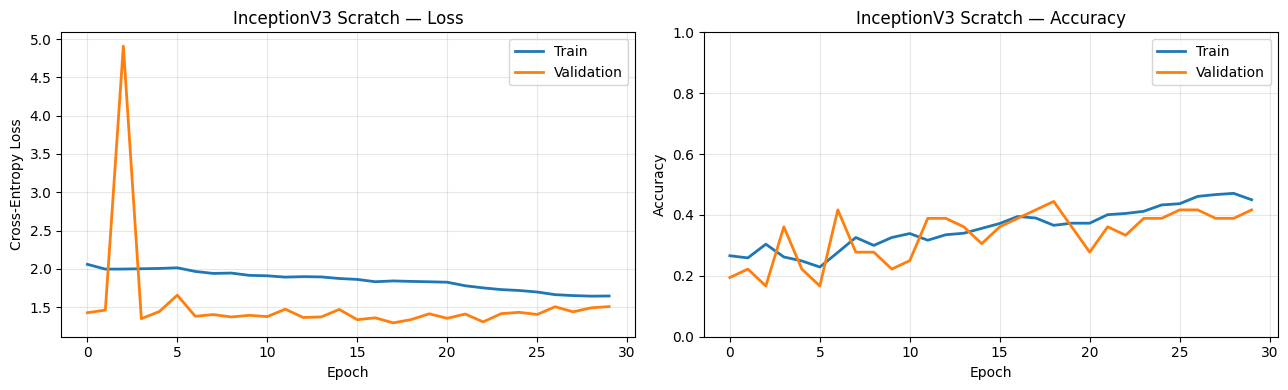

  Curve saved → history_InceptionV3_Scratch.png

  Evaluating on test set...


  running inference:   0%|          | 0/2 [00:00<?, ?batch/s]


  InceptionV3 from Scratch — Test Set
  Accuracy  : 0.2368
  Precision : 0.2395  (macro avg)
  Recall    : 0.2470  (macro avg)
  F1-Score  : 0.2365  (macro avg)

              precision    recall  f1-score   support

       Angry       0.29      0.20      0.24        10
       Other       0.20      0.33      0.25         6
         Sad       0.25      0.27      0.26        11
       happy       0.22      0.18      0.20        11

    accuracy                           0.24        38
   macro avg       0.24      0.25      0.24        38
weighted avg       0.24      0.24      0.23        38



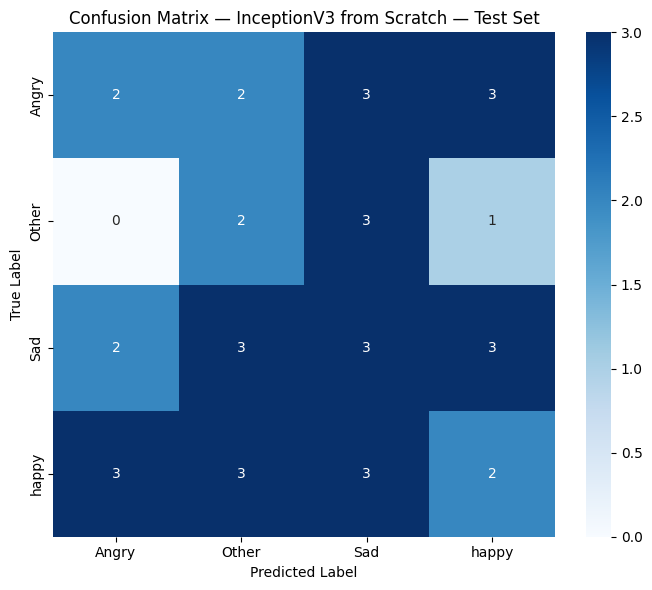

  Saved → confusion_matrix_InceptionV3_from_Scratch_—_Test_Set.png
  Weights saved → inception_v3_scratch.pth


In [20]:
# ── Build scratch model ───────────────────────────────────────────────────────
print("="*60)
print("  PART 1 — Inception V3 from Scratch")
print("="*60)

scratch_model = InceptionV3Scratch(
    num_classes=NUM_CLASSES, aux_logits=True, dropout=0.5).to(DEVICE)

n_params     = sum(p.numel() for p in scratch_model.parameters())
n_trainable  = sum(p.numel() for p in scratch_model.parameters() if p.requires_grad)
print(f"  Total parameters     : {n_params:>12,}")
print(f"  Trainable parameters : {n_trainable:>12,}")
print(f"  Approx model size    : {n_params * 4 / 1e6:.1f} MB  (float32)")

# ── Train ─────────────────────────────────────────────────────────────────────
scratch_model, scratch_hist = train_model_scratch(
    scratch_model, train_loader, valid_loader,
    epochs=EPOCHS, device=DEVICE, lr=LR_SCRATCH,
)

# ── Training curves ───────────────────────────────────────────────────────────
plot_history(scratch_hist, title="InceptionV3 Scratch")

# ── Evaluate on test set ──────────────────────────────────────────────────────
print("\n  Evaluating on test set...")
scratch_metrics = evaluate_scratch(
    scratch_model, test_loader, DEVICE, CLASS_NAMES,
    title="InceptionV3 from Scratch — Test Set",
)

# ── Save weights ──────────────────────────────────────────────────────────────
torch.save(scratch_model.state_dict(), "inception_v3_scratch.pth")
print("  Weights saved → inception_v3_scratch.pth")

---
## 9 — Part 2: Transfer Learning with ImageNet Weights

**What happens below:**
1. `torchvision.models.inception_v3` is loaded with ImageNet weights (auto-downloaded ~100 MB on first run)  
2. Both classification heads are replaced (printed for verification)  
3. Fine-tuning runs for 30 epochs with a *lower* learning rate (`1e-4`)  
4. Training curves are plotted  
5. Best checkpoint is evaluated on the test set — results should be **noticeably better** than Part 1  
6. Weights saved to `inception_v3_transfer.pth`

  PART 2 — Transfer Learning  (ImageNet → InceptionV3)
  AuxLogits.fc replaced: 768 → 4
  fc replaced           : 2048 → 4
  Total parameters     :   24,354,536
  Trainable parameters :   24,354,536

  Starting fine-tuning — 30 epochs, lr=0.0001, device=cuda
  (First batch may be slow while CUDA kernels are compiled...)

  ┌─ Epoch   1/30 ─────────────────────


  training:   0%|          | 0/32 [00:00<?, ?batch/s]

  validating:   0%|          | 0/2 [00:00<?, ?batch/s]

  └─ Train loss=1.7156 acc=0.4460  │  Val loss=1.2582 acc=0.3611 ← best
  ┌─ Epoch   2/30 ─────────────────────


  training:   0%|          | 0/32 [00:00<?, ?batch/s]

...

  validating:   0%|          | 0/2 [00:00<?, ?batch/s]

  └─ Train loss=0.0153 acc=0.9980  │  Val loss=2.2671 acc=0.4444
  ┌─ Epoch  30/30 ─────────────────────


  training:   0%|          | 0/32 [00:00<?, ?batch/s]

  validating:   0%|          | 0/2 [00:00<?, ?batch/s]

  └─ Train loss=0.0118 acc=1.0000  │  Val loss=2.3034 acc=0.4444

  ✓ Fine-tuning complete — best val accuracy: 0.5278


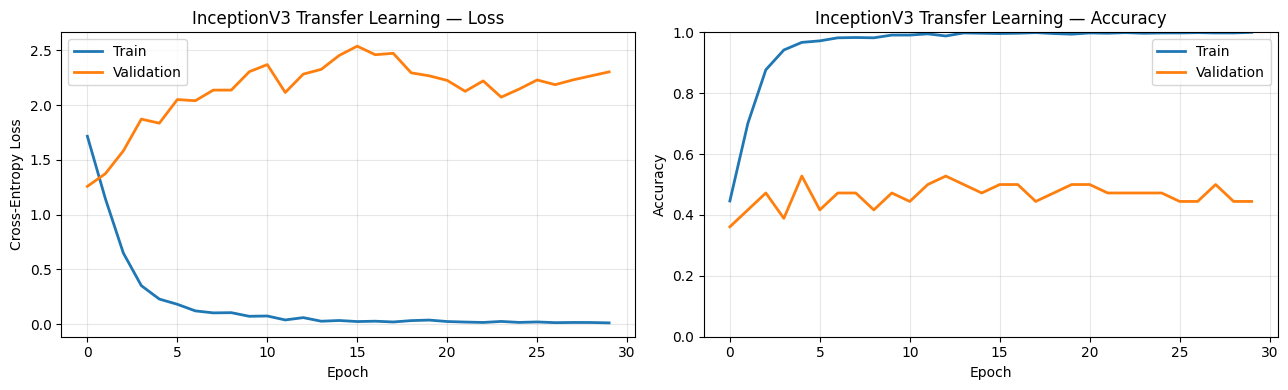

  Curve saved → history_InceptionV3_Transfer_Learning.png

  Evaluating on test set...


  running inference:   0%|          | 0/2 [00:00<?, ?batch/s]


  InceptionV3 Transfer Learning — Test Set
  Accuracy  : 0.4211
  Precision : 0.4016  (macro avg)
  Recall    : 0.3917  (macro avg)
  F1-Score  : 0.3855  (macro avg)

              precision    recall  f1-score   support

       Angry       0.44      0.40      0.42        10
       Other       0.25      0.17      0.20         6
         Sad       0.41      0.64      0.50        11
       happy       0.50      0.36      0.42        11

    accuracy                           0.42        38
   macro avg       0.40      0.39      0.39        38
weighted avg       0.42      0.42      0.41        38



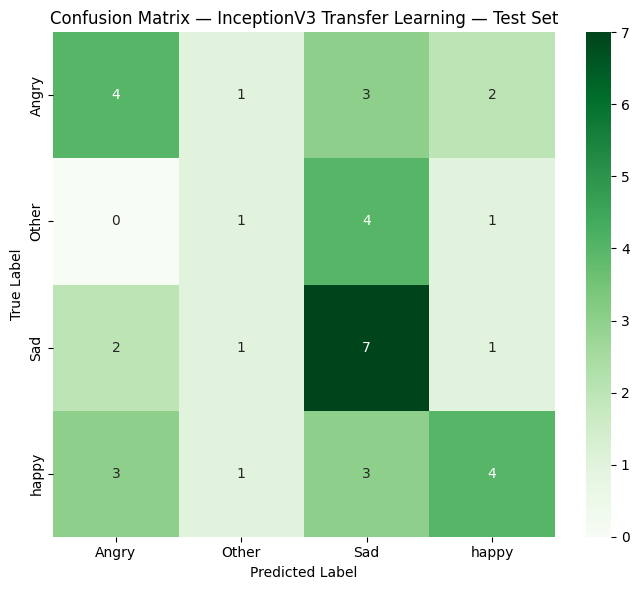

  Saved → confusion_matrix_InceptionV3_Transfer_Learning_—_Test_Set.png
  Weights saved → inception_v3_transfer.pth


In [18]:
# ── Build transfer-learning model ────────────────────────────────────────────
print("="*60)
print("  PART 2 — Transfer Learning  (ImageNet → InceptionV3)")
print("="*60)

tl_model = build_transfer_model(NUM_CLASSES).to(DEVICE)

n_params_tl    = sum(p.numel() for p in tl_model.parameters())
n_trainable_tl = sum(p.numel() for p in tl_model.parameters() if p.requires_grad)
print(f"  Total parameters     : {n_params_tl:>12,}")
print(f"  Trainable parameters : {n_trainable_tl:>12,}")

# ── Fine-tune ─────────────────────────────────────────────────────────────────
tl_model, tl_hist = train_model_tl(
    tl_model, train_loader, valid_loader,
    epochs=EPOCHS, device=DEVICE, lr=LR_TL,
)

# ── Training curves ───────────────────────────────────────────────────────────
plot_history(tl_hist, title="InceptionV3 Transfer Learning")

# ── Evaluate on test set ──────────────────────────────────────────────────────
print("\n  Evaluating on test set...")
tl_metrics = evaluate_tl(
    tl_model, test_loader, DEVICE, CLASS_NAMES,
    title="InceptionV3 Transfer Learning — Test Set",
)

# ── Save weights ──────────────────────────────────────────────────────────────
torch.save(tl_model.state_dict(), "inception_v3_transfer.pth")
print("  Weights saved → inception_v3_transfer.pth")

---
## 10 — Side-by-Side Comparison

The table below compares all four metrics between the two models. Positive Δ values (↑) mean transfer learning improved over training from scratch.

In [19]:
print_comparison(scratch_metrics, tl_metrics)


  COMPARISON  —  Scratch  vs.  Transfer Learning (ImageNet)
  Metric                Scratch       Transfer Learning    Δ (TL − Scr)
  ──────────────────────────────────────────────────────────────
  Accuracy               0.3158                  0.4211        ↑ 0.1053
  Precision              0.3226                  0.4016        ↑ 0.0789
  Recall                 0.3152                  0.3917        ↑ 0.0765
  F1                     0.3159                  0.3855        ↑ 0.0696
